Imports & Setup

In [1]:
import numpy as np
import scipy.io
from scipy.signal import hilbert, butter, filtfilt
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# Configuration
FS = 2000  # Sampling Rate
WINDOW_SIZE_MS = 200
WINDOW_SAMPLES = int((WINDOW_SIZE_MS / 1000) * FS)
LFP_FILENAME = 'LFPData.mat'  # <--- Make sure this file exists
EVENT_FILENAME = 'EventMatrix.mat'

# Frequency bands
PHASE_BAND = [4, 8]   # Theta
AMP_BAND = [30, 80]   # Gamma

Helper Functions (Loading & Filtering)

In [2]:
def load_data(event_path, lfp_path):
    print(f"Loading events from {event_path}...")
    try:
        events_mat = scipy.io.loadmat(event_path)
        event_matrix = events_mat['EventMatrix']
    except FileNotFoundError:
        print("Event file not found.")
        return None, None

    print(f"Loading LFP data from {lfp_path}...")
    try:
        lfp_mat = scipy.io.loadmat(lfp_path)
        keys = [k for k in lfp_mat.keys() if not k.startswith('_')]
        lfp_key = max(keys, key=lambda k: lfp_mat[k].size)
        lfp_data = lfp_mat[lfp_key]
        print(f"LFP Data Loaded. Shape: {lfp_data.shape}")
    except FileNotFoundError:
        print("LFP file not found.")
        return None, None
    return event_matrix, lfp_data

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

PAC Analysis Function

In [3]:
def compute_pac_features(lfp_data):
    n_sessions, n_regions, n_trials, n_samples = lfp_data.shape
    n_windows = n_samples // WINDOW_SAMPLES
    
    # Define Region Pairs (Indices: 0=HC, 1=dS, 2=mPFC)
    # We test: HC->mPFC (0->2), HC->dS (0->1)
    # You can add dS->mPFC (1->2) if needed.
    pairs = [(0, 2), (0, 1), (1, 2)] 
    
    # Initialize Feature Space
    pac_matrix = np.zeros((n_sessions, len(pairs), n_trials, n_windows))
    
    print(f"Starting PAC extraction on {n_sessions} sessions...")
    
    for s in range(n_sessions):
        print(f"  Processing Session {s+1}/{n_sessions}")
        for p_idx, (r_phase, r_amp) in enumerate(pairs):
            phase_sig = butter_bandpass_filter(lfp_data[s, r_phase], PHASE_BAND[0], PHASE_BAND[1], FS)
            amp_sig = butter_bandpass_filter(lfp_data[s, r_amp], AMP_BAND[0], AMP_BAND[1], FS)
            
            # 2. Hilbert Transform
            phase_ts = np.angle(hilbert(phase_sig, axis=-1))
            amp_ts = np.abs(hilbert(amp_sig, axis=-1))
            
            # 3. Sliding Window Analysis
            for w in range(n_windows):
                start, end = w*WINDOW_SAMPLES, (w+1)*WINDOW_SAMPLES
                
                # Slicing
                p_win = phase_ts[:, start:end] # (Trials, Samples)
                a_win = amp_ts[:, start:end]
                
                # 4. Compute Mean Vector Length (MVL)
                # z = A * exp(i * phi)
                z = a_win * np.exp(1j * p_win)
                # Mean over time samples -> (Trials,)
                mvl = np.abs(np.mean(z, axis=1))
                
                pac_matrix[s, p_idx, :, w] = mvl
                
    return pac_matrix

Granger Causality Function

In [4]:
def compute_granger_for_window(lfp_data, event_matrix, target_window_idx=5):
    """
    Computes Granger Causality for a specific window (e.g., Win 5) to save time.
    Focus: HC -> dS
    """
    print(f"\nComputing Granger Causality (HC -> dS) for Window {target_window_idx}...")
    n_sessions, _, n_trials, _ = lfp_data.shape
    start_samp = target_window_idx * WINDOW_SAMPLES
    end_samp = (target_window_idx + 1) * WINDOW_SAMPLES
    
    gc_values = {'Standard': [], 'Target': []}
    
    for s in range(n_sessions):
        for t in range(n_trials):
            condition = 'Standard' if event_matrix[s, t] == 1 else 'Target'
            
            # Source: HC (0), Target: dS (1)
            src = lfp_data[s, 0, t, start_samp:end_samp]
            tgt = lfp_data[s, 1, t, start_samp:end_samp]
            
            # Create DataFrame
            df = pd.DataFrame({'tgt': tgt, 'src': src})
            
            # Run Granger Test (lag=2)
            try:
                # verbose=False suppresses print output
                res = grangercausalitytests(df, maxlag=[2], verbose=False)
                # Extract F-test statistic
                f_score = res[2][0]['ssr_ftest'][0]
                gc_values[condition].append(f_score)
            except:
                continue

    return gc_values

STATISTICAL TESTING & VISUALIZATION

Loading events from EventMatrix.mat...
Loading LFP data from LFPData.mat...
LFP Data Loaded. Shape: (14, 3, 120, 3481)
Starting PAC extraction on 14 sessions...
  Processing Session 1/14
  Processing Session 2/14
  Processing Session 3/14
  Processing Session 4/14
  Processing Session 5/14
  Processing Session 6/14
  Processing Session 7/14
  Processing Session 8/14
  Processing Session 9/14
  Processing Session 10/14
  Processing Session 11/14
  Processing Session 12/14
  Processing Session 13/14
  Processing Session 14/14

--- Statistical Results: HC -> dS (PAC) ---
Window 0: p=0.3249 
Window 1: p=0.2393 
Window 2: p=0.1043 
Window 3: p=0.9689 
Window 4: p=0.3645 
Window 5: p=0.4964 
Window 6: p=0.9373 
Window 7: p=0.8736 

Computing Granger Causality (HC -> dS) for Window 5...


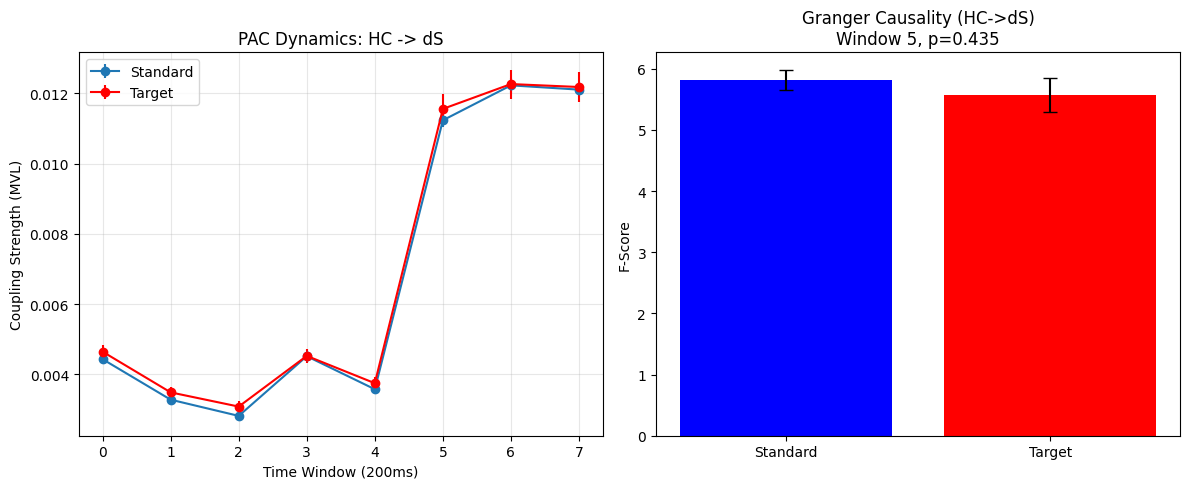

In [9]:
def run_analysis_pipeline():
    # 1. Load Data
    events, lfp = load_data(EVENT_FILENAME, LFP_FILENAME)
    if lfp is None: return

    # 2. Extract PAC Features
    pac_features = compute_pac_features(lfp)
    # Shape: (14, 2, 120, 17) approx (depends on sample count)
    
    # 3. Statistical Comparison (Welch's t-test)
    # Focus on Pair 1: HC -> dS (Index 1 in our pairs list)
    pair_idx = 1 
    pair_name = "HC -> dS"
    
    # Flatten sessions to get (TotalTrials, Windows)
    # pac_features[:, pair_idx, :, :] -> (14, 120, Windows)
    n_wins = pac_features.shape[3]
    X_flat = pac_features[:, pair_idx, :, :].reshape(-1, n_wins)
    y_flat = events.flatten()
    
    # Split by condition
    std_data = X_flat[y_flat == 1]
    tgt_data = X_flat[y_flat == 2]
    
    print(f"\n--- Statistical Results: {pair_name} (PAC) ---")
    p_values = []
    
    for w in range(n_wins):
        # Welch's t-test (equal_var=False)
        t_stat, p_val = stats.ttest_ind(tgt_data[:, w], std_data[:, w], equal_var=False)
        p_values.append(p_val)
        sig = "*" if p_val < 0.05 else ""
        print(f"Window {w}: p={p_val:.4f} {sig}")
        
    # 4. Visualization (Task D: Task 4)
    plt.figure(figsize=(12, 5))
    
    # Plot 1: PAC Time Course
    plt.subplot(1, 2, 1)
    mean_std = np.mean(std_data, axis=0)
    mean_tgt = np.mean(tgt_data, axis=0)
    sem_std = stats.sem(std_data, axis=0)
    sem_tgt = stats.sem(tgt_data, axis=0)
    
    plt.errorbar(range(n_wins), mean_std, yerr=sem_std, label='Standard', fmt='-o')
    plt.errorbar(range(n_wins), mean_tgt, yerr=sem_tgt, label='Target', fmt='-o', color='red')
    
    # Mark significance
    for w, p in enumerate(p_values):
        if p < 0.05:
            plt.text(w, max(mean_tgt[w], mean_std[w]), '*', fontsize=15, ha='center')
            
    plt.title(f'PAC Dynamics: {pair_name}')
    plt.xlabel('Time Window (200ms)')
    plt.ylabel('Coupling Strength (MVL)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 5. Extra Credit: Granger Causality Analysis
    # Analyze only a specific window (e.g., Window 5 where we might expect P300)
    gc_res = compute_granger_for_window(lfp, events, target_window_idx=5)
    
    # Stats for GC
    t_gc, p_gc = stats.ttest_ind(gc_res['Target'], gc_res['Standard'], equal_var=False)
    
    # Plot 2: Granger Causality Bar Plot
    plt.subplot(1, 2, 2)
    means = [np.mean(gc_res['Standard']), np.mean(gc_res['Target'])]
    sems = [stats.sem(gc_res['Standard']), stats.sem(gc_res['Target'])]
    
    plt.bar(['Standard', 'Target'], means, yerr=sems, capsize=5, color=['blue', 'red'])
    plt.title(f'Granger Causality (HC->dS)\nWindow 5, p={p_gc:.3f}')
    plt.ylabel('F-Score')
    
    plt.tight_layout()
    plt.show()

# Run the pipeline
if __name__ == "__main__":
    run_analysis_pipeline()

Main Execution & Plotting

Studying the shape of t-distribution

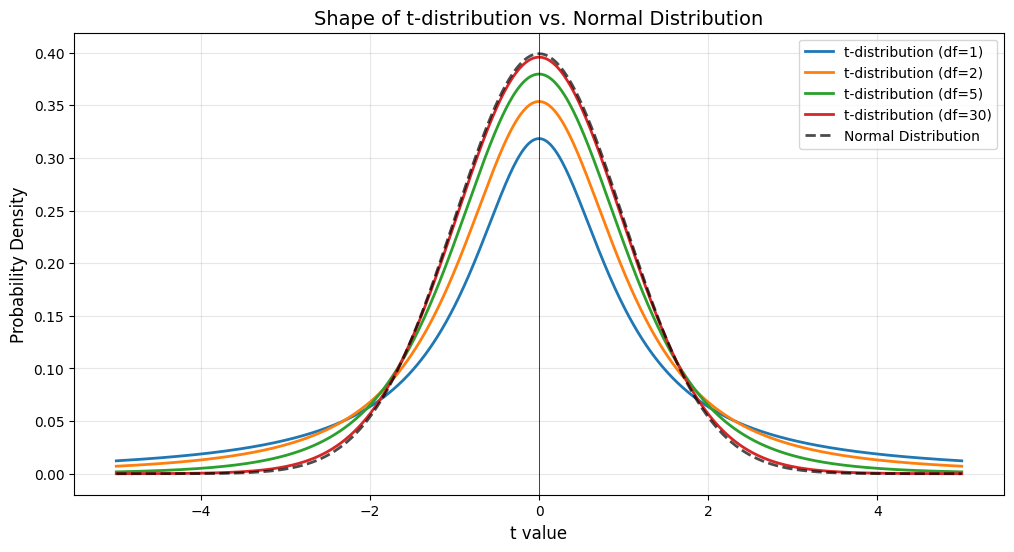

------------------------------------------------------------
CONCEPTUAL ANSWERS:
1. Average (Mean) of t-distribution under Null Hypothesis: 0
2. Most Probable Point (Mode) of t-distribution: 0
(The distribution is symmetric around 0 for df > 1)
------------------------------------------------------------

CALCULATED CRITICAL t-VALUES:
df    | p-value (alpha) | Critical t (|t|)    
---------------------------------------------
5     | 0.05            | 2.5706
5     | 0.1             | 2.0150
10    | 0.05            | 2.2281
10    | 0.1             | 1.8125
20    | 0.05            | 2.0860
20    | 0.1             | 1.7247
50    | 0.05            | 2.0086
50    | 0.1             | 1.6759
100   | 0.05            | 1.9840
100   | 0.1             | 1.6602


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# =============================================================================
# Task P Part 1: Studying the shape of t-distribution
# =============================================================================

# 1. Define the range of x values (t-scores)
x = np.linspace(-5, 5, 1000)

# 2. Define different degrees of freedom (df) to visualize
# Small df has heavier tails; large df approaches normal distribution.
degrees_of_freedom = [1, 2, 5, 30]

# 3. Plotting
plt.figure(figsize=(12, 6))

# Plot t-distributions for each df
for df in degrees_of_freedom:
    plt.plot(x, t.pdf(x, df), label=f't-distribution (df={df})', linewidth=2)

# Plot Standard Normal Distribution for comparison (df -> infinity)
plt.plot(x, norm.pdf(x), 'k--', label='Normal Distribution', linewidth=2, alpha=0.7)

# Formatting the plot
plt.title('Shape of t-distribution vs. Normal Distribution', fontsize=14)
plt.xlabel('t value', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5) # Mark the center

plt.show()

# =============================================================================
# Answers to Conceptual Questions
# =============================================================================
print("-" * 60)
print("CONCEPTUAL ANSWERS:")
print("1. Average (Mean) of t-distribution under Null Hypothesis: 0")
print("2. Most Probable Point (Mode) of t-distribution: 0")
print("(The distribution is symmetric around 0 for df > 1)")
print("-" * 60)

# =============================================================================
# Task P Part 2: Calculate t values for specific p-values
# =============================================================================
# We need to find 't' such that p(|t'| > t) = 0.05 and p(|t'| > t) = 0.1
# This corresponds to a two-tailed test.
# p(|t'| > t) = alpha  =>  Area in both tails = alpha
# Area in one tail = alpha / 2
# Cumulative probability (CDF) up to t = 1 - (alpha / 2)

alphas = [0.05, 0.1]
test_dfs = [5, 10, 20, 50, 100] # Examples of small to large sample sizes

print("\nCALCULATED CRITICAL t-VALUES:")
print(f"{'df':<5} | {'p-value (alpha)':<15} | {'Critical t (|t|)':<20}")
print("-" * 45)

for df in test_dfs:
    for alpha in alphas:
        # ppf is the Percent Point Function (inverse of CDF)
        # We want the t-value where the area to the RIGHT is alpha/2
        # So we look for the point where area to the LEFT is 1 - alpha/2
        t_crit = t.ppf(1 - alpha/2, df)
        
        print(f"{df:<5} | {alpha:<15} | {t_crit:.4f}")